In [13]:
# import libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

In [56]:
# download 2 years EURUSD daily data
data = yf.download("EURUSD=X", period="5y", interval="1d")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2021-05-26  1.224909  1.226500  1.220003  1.224890        0
2021-05-27  1.219260  1.221699  1.217567  1.219036        0
2021-05-28  1.219319  1.220107  1.213342  1.219274        0
2021-05-31  1.219007  1.223391  1.218413  1.219007        0
2021-06-01  1.223287  1.225415  1.221464  1.223406        0


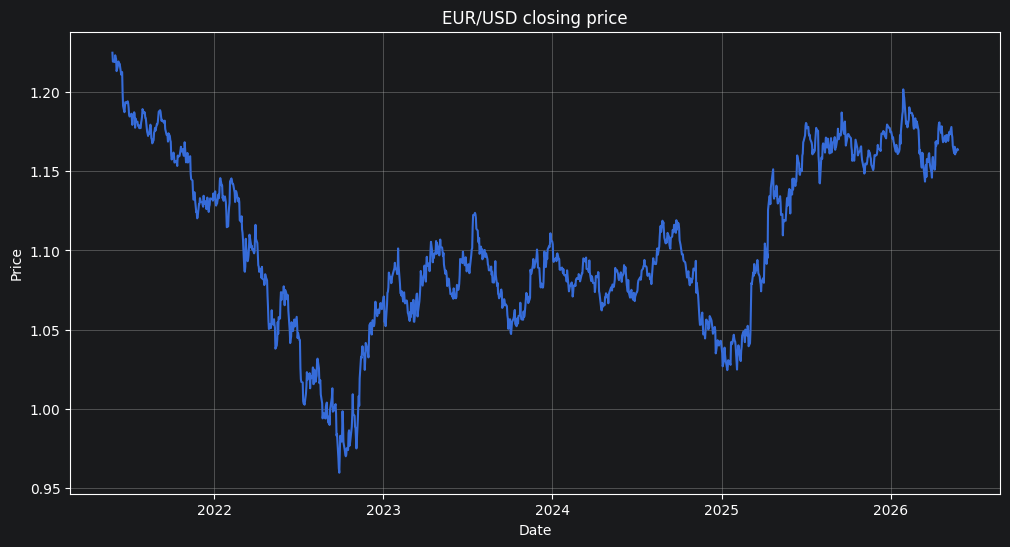

In [57]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("EUR/USD closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [58]:
# returns of of the eurusd
data['returns'] = data['Close'].pct_change()
print(data.head())

Price          Close      High       Low      Open   Volume   returns
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X          
Date                                                                 
2021-05-26  1.224909  1.226500  1.220003  1.224890        0       NaN
2021-05-27  1.219260  1.221699  1.217567  1.219036        0 -0.004612
2021-05-28  1.219319  1.220107  1.213342  1.219274        0  0.000049
2021-05-31  1.219007  1.223391  1.218413  1.219007        0 -0.000256
2021-06-01  1.223287  1.225415  1.221464  1.223406        0  0.003511


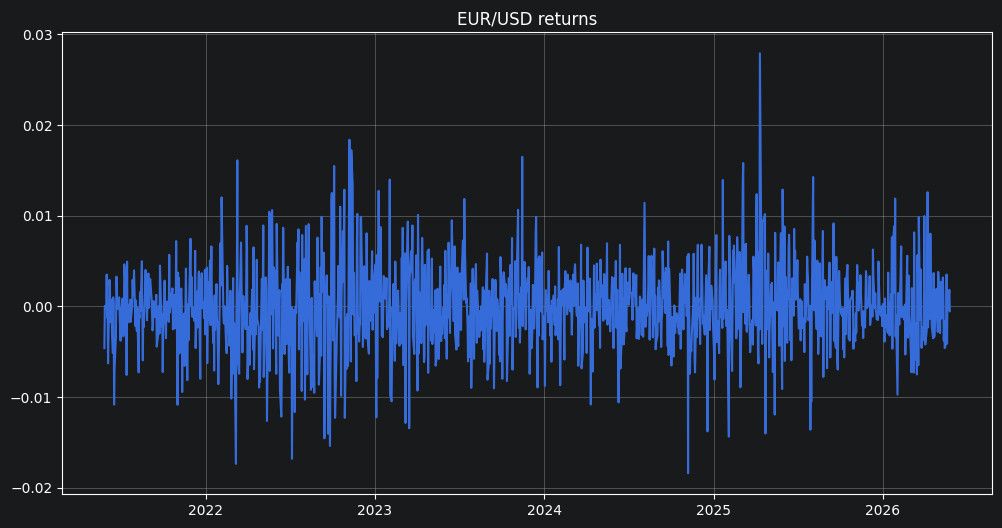

In [59]:
# we plot the returns
plt.figure(figsize=(12,6))
plt.plot(data['returns'])
plt.title("EUR/USD returns")
plt.grid()
plt.show()

mean -2.8251278924074976e-05
std  0.004752124285466798
skewness 0.23295609516467566


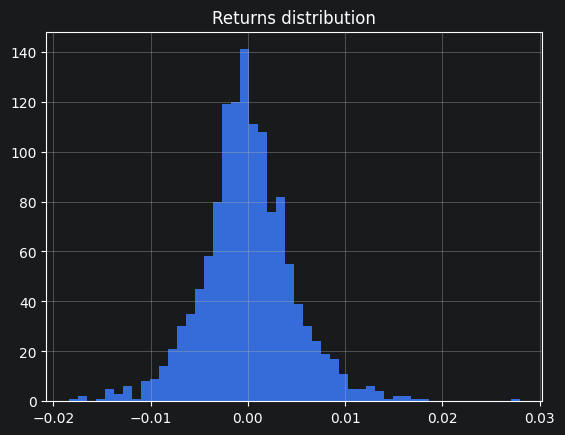

In [60]:

print(f"mean {data['returns'].mean()}") # the mean
print(f"std  {data['returns'].std()}") # the standard deviation
print(f"skewness {(skew(data['returns'].dropna()))}") # the skewness
data['returns'].hist(bins=50) # plot return histogram
plt.title("Returns distribution")
plt.show()



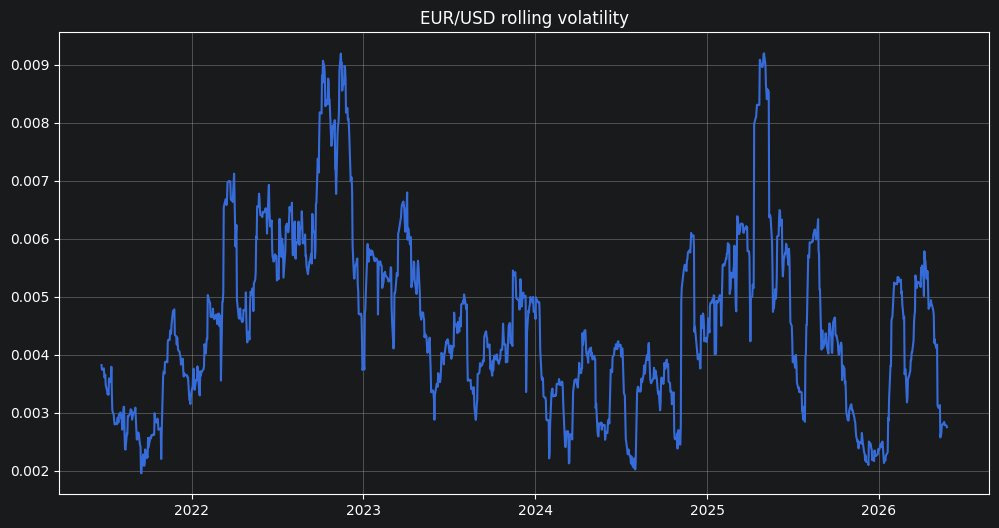

In [61]:
#volatility analysis
# the rolling calculation means, we continouslt recalculate statistics over a moving window
data['volatility'] = data['returns'].rolling(20).std() # take previous 20 days, compute stadnard deviation, move forward one day, repeat again.
plt.figure(figsize=(12,6))
plt.plot(data['volatility'])
plt.title("EUR/USD rolling volatility")
plt.grid()
plt.show()

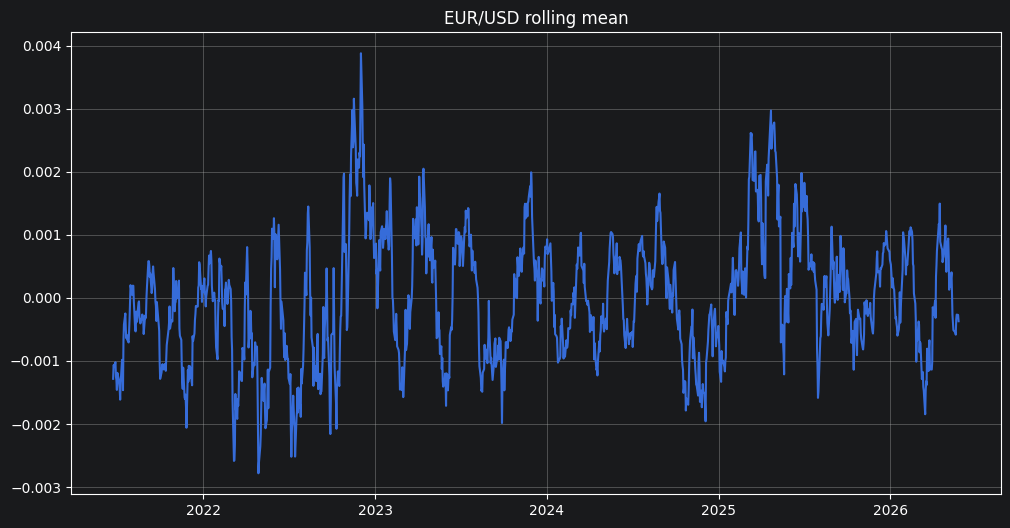

In [62]:
# calculating rolling mean, rolling skew, rolling correlation, rolling momentum
data['rolling_mean'] = data['returns'].rolling(20).mean()
plt.figure(figsize=(12,6))
plt.plot(data['rolling_mean'])
plt.title("EUR/USD rolling mean")
plt.grid()
plt.show()

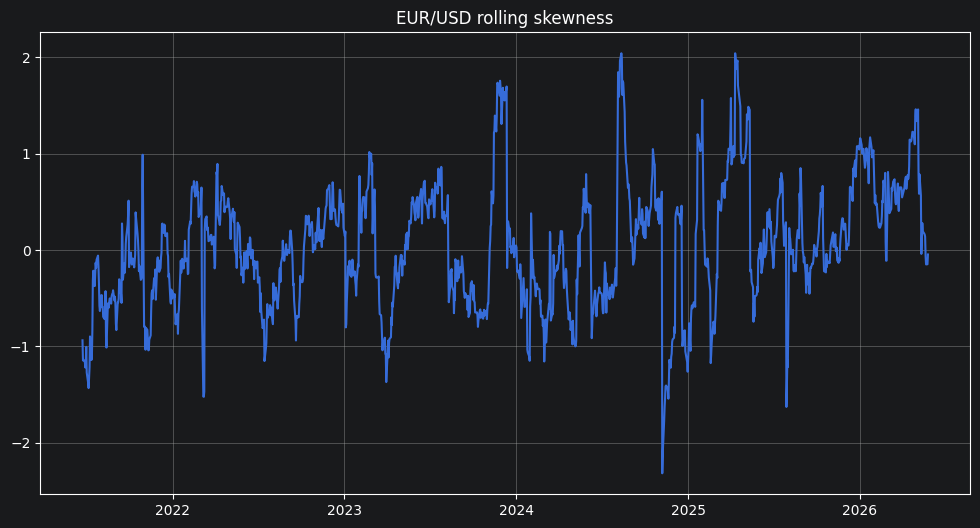

In [63]:
# calculating rolling skewness
data['rolling_skewness'] = data['returns'].rolling(20).skew()
plt.figure(figsize=(12,6))
plt.plot(data['rolling_skewness'])
plt.title("EUR/USD rolling skewness")
plt.grid()
plt.show()

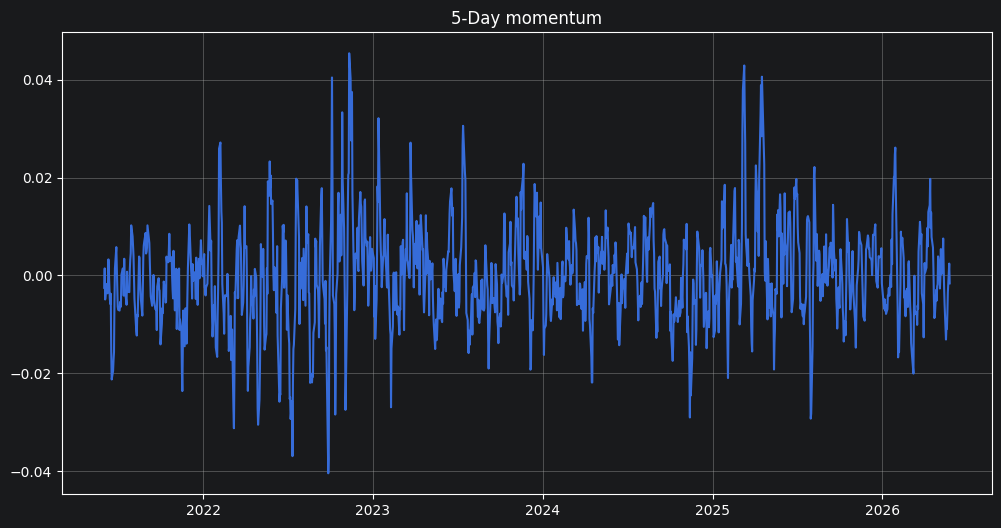

In [64]:
# We are checking for momentum, for example, how much price changed over period of 5 days
data['momentum_5'] = data['Close'].pct_change(5)
plt.figure(figsize=(12,6))
plt.plot(data['momentum_5'])
plt.title("5-Day momentum")
plt.grid()
plt.show()



Market Mean Return:
-2.8251278924074976e-05
Strategy Mean Return:
-3.802320500875527e-05


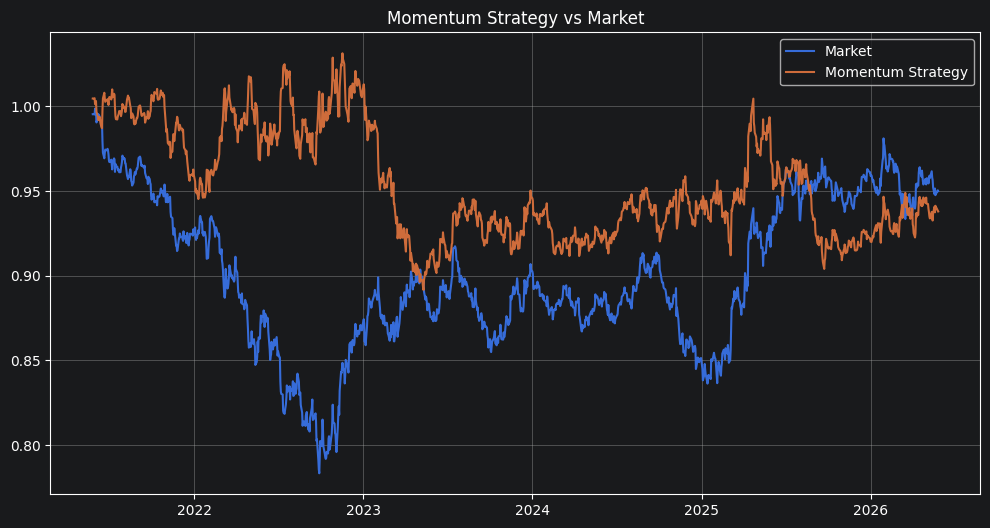

In [65]:
#trading logic
# if 5 day momentum positive: go Long tomorrow
# if 5 day momentum negative: go short tomorrow
data['signal'] = np.where(data['momentum_5'] > 0, 1, -1) # 1 bullish, -1 bearish


# we test wether momentum has predictive power
data['strategy_returns'] = data['signal'].shift(1) * data['returns']

# now, we compare performance, we compare market mean return and the strategy mean return
print("Market Mean Return:")
print(data['returns'].mean())

print("Strategy Mean Return:")
print(data['strategy_returns'].mean())

# we visualize it
market = (1 + data['returns']).cumprod()
strategy = (1 + data['strategy_returns']).cumprod()
plt.figure(figsize=(12,6))
plt.plot(market, label='Market')
plt.plot(strategy, label='Momentum Strategy')
plt.legend()
plt.title("Momentum Strategy vs Market")
plt.grid()
plt.show()


In [66]:
# we evaluate sharpe ratio, which is the return per unit risk. (note: 252 is number of trading days/year)
sharpe = (data['strategy_returns'].mean() / data['strategy_returns'].std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe}")

# Now we look at maximum drawdown
cumulative = (1 + data['strategy_returns']).cumprod()
rolling_max = cumulative.cummax()

drawdown = (cumulative - rolling_max) / rolling_max

max_drawdown = drawdown.min()
print(f"Max Drawdown: {max_drawdown}")


Sharpe Ratio: -0.1270186326511684
Max Drawdown: -0.13544026018404023


In [67]:
# we try to refine the strategy to specific market regime

vol_threshold = data['volatility'].median()

# we create filter, this means only go long if momentum positive and volatility high, otherwise no trade.
data['filtered_signal'] = np.where(
    (data['momentum_5'] > 0) &
    (data['volatility'] > vol_threshold),
    1, 0
)


# we filter the strategy return
data['filtered_returns'] = (
    data['filtered_signal'].shift(1) * data['returns']
)

# recalculate the sharpe ratio
filtered_sharpe = (
    data['filtered_returns'].mean() / data['filtered_returns'].std()
) * np.sqrt(252)

print(filtered_sharpe)

-0.1294288279467779


In [68]:
# we try trend filter to see if momentum work in trend
data['ma_50'] = (
    data['Close']
     .squeeze()
     .rolling(50)
     .mean()
                 )

# we test to see, only trade momentum if price is above 50 MA
data['trend_signal'] = np.where(
    (data['momentum_5'] > 0) &
    (data['Close'].squeeze() > data['ma_50']),
    1,
    0
)

# trend strategy returns
data['trend_returns'] = (
    data['trend_signal'].shift(1) * data['returns']
)

# we calculate the sharpe ratio
trend_sharpe = (data['trend_returns'].mean()
                /
                data['trend_returns'].std()
                ) * np.sqrt(252)
print(f"Trend Sharpe: {trend_sharpe}")

Trend Sharpe: 0.02592771558058129


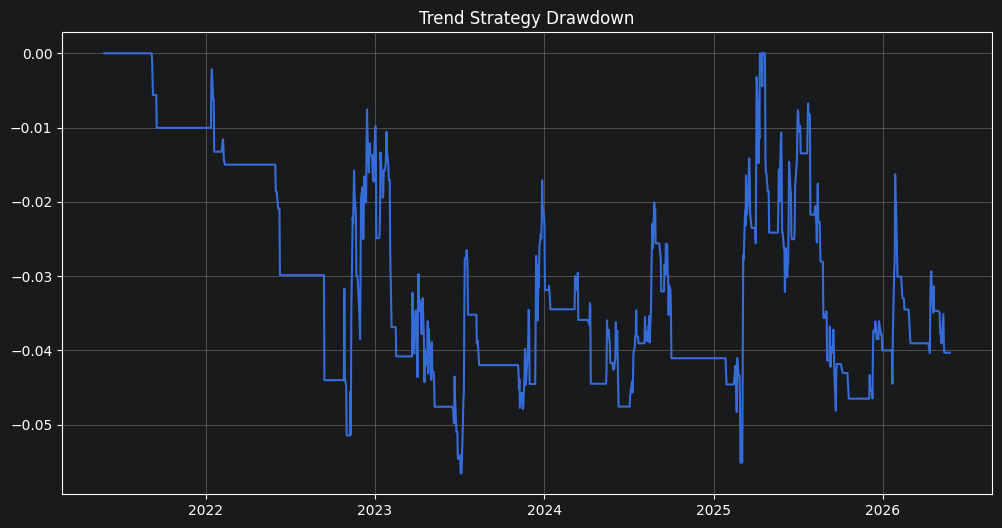

In [69]:
# The drawdown curve of trend following strategy
trend_cumulative = (
    1 + data['trend_returns']
).cumprod()

trend_rolling_max = (
    trend_cumulative.cummax()
)

trend_drawdown = (
    trend_cumulative - trend_rolling_max
) / trend_rolling_max


# we plot the drawdown
plt.figure(figsize=(12,6))
plt.plot(trend_drawdown)
plt.title("Trend Strategy Drawdown")
plt.grid()
plt.show()

In [70]:
# we try combined strategy, we combine momentum, trend and volatility
data['combined_signal'] = np.where(
    (
    (data['momentum_5'] > 0)
        &
    (data['Close'].squeeze() > data['ma_50'])
    &
    (data['volatility'] > vol_threshold)
    ),
    1,
    0
)

# we calculate the strategy return
data['combined_returns'] = (
    data['combined_signal'].shift(1)
    * data['returns']
)

# we calculate the sharpe ratio
combined_sharpe = (
    data['combined_returns'].mean()
    /
    data['combined_returns'].std()
) * np.sqrt(252)

print(f"Combined sharpe: {combined_sharpe}")


Combined sharpe: -0.08852478141460421


Long/Short Sharpe: 0.0964680055019007


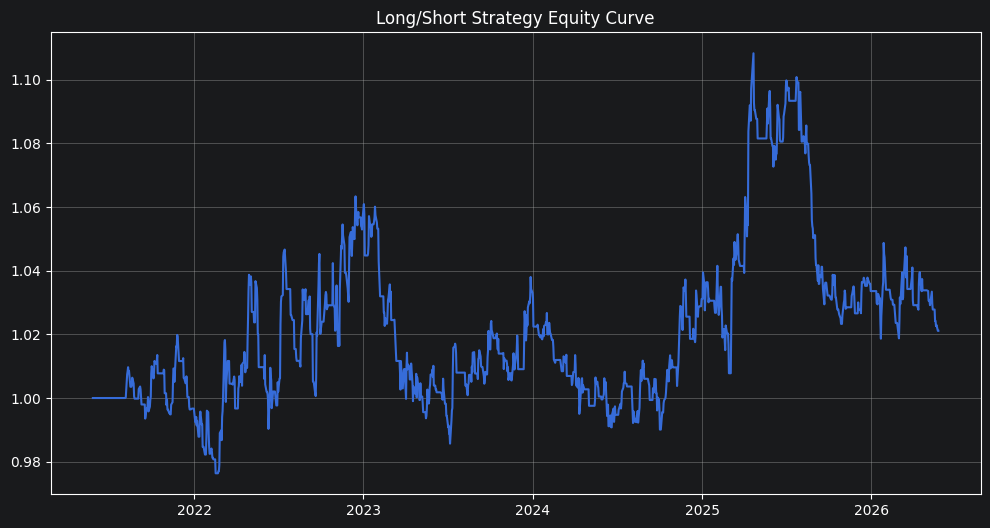

In [71]:
# we experiment the strategy for long and short approach
data['ls_signal'] = np.where(
    (
    (data['momentum_5'] > 0)
    &
    (data['Close'].squeeze() > data['ma_50'])
),
1,
    np.where(
        (
        (data['momentum_5'] < 0)
            &
        (data['Close'].squeeze() < data['ma_50'])
        ),
        -1,
        0
    )
)


# we check the return
data['ls_signal'] = (
    data['ls_signal'].shift(1) * data['returns']
)

# we calculate the sharpe ratio
ls_sharpe = (
    data['ls_signal'].mean()
    /
    data['ls_signal'].std()
) * np.sqrt(252)

print(f"Long/Short Sharpe: {ls_sharpe
}")


# now we plot the equity curve
ls_equity = (
    1 + data['ls_signal']
).cumprod()
plt.figure(figsize=(12,6))
plt.plot(ls_equity)
plt.title("Long/Short Strategy Equity Curve")
plt.grid()
plt.show()

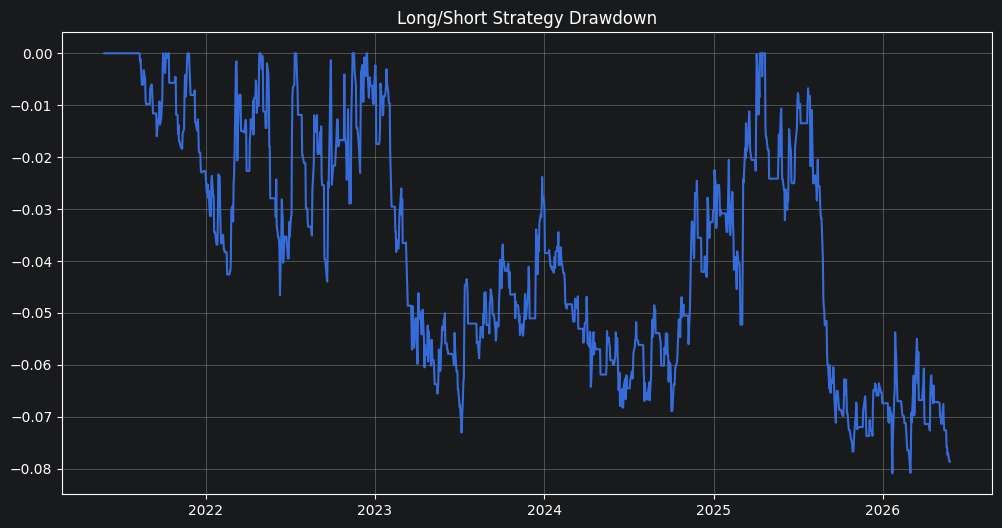

In [72]:
# we calculate the drawdown
ls_rolling_max = ls_equity.cummax()

ls_drawdown = (
    ls_equity - ls_rolling_max
) / ls_rolling_max

plt.figure(figsize=(12,6))
plt.plot(ls_drawdown)
plt.title("Long/Short Strategy Drawdown")
plt.grid()
plt.show()

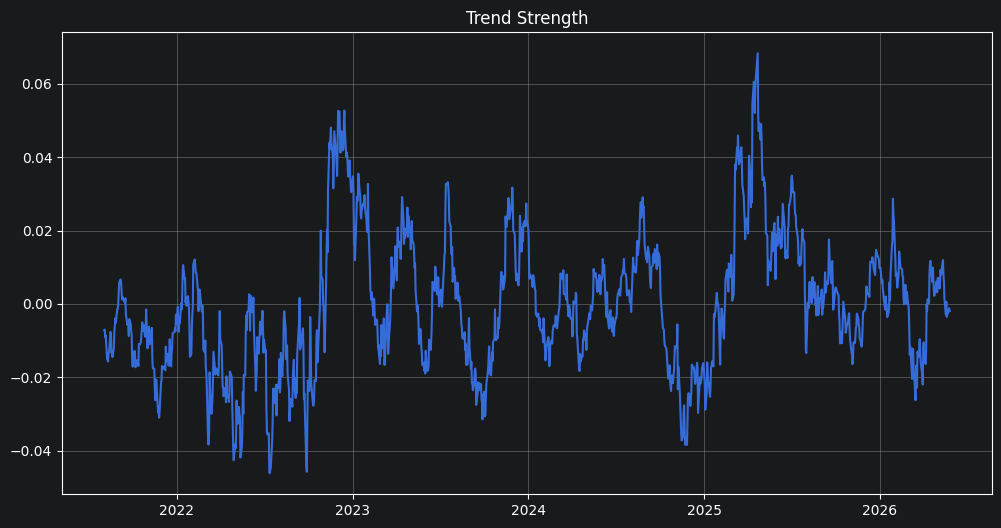

In [73]:
# Trend strength metic. i.e how far price is from MA50 (large positive means strong bullish trend, and large negative mean strong bearish trend,
# near zero means ranging/choppy market)
data['trend_strength'] = (
(data['Close'].squeeze() - data['ma_50']) / data['ma_50']
)

# we visualize it
plt.figure(figsize=(12,6))
plt.plot(data['trend_strength'])
plt.title("Trend Strength")
plt.grid()
plt.show()

Regime Sharpe: -0.08385753047875939


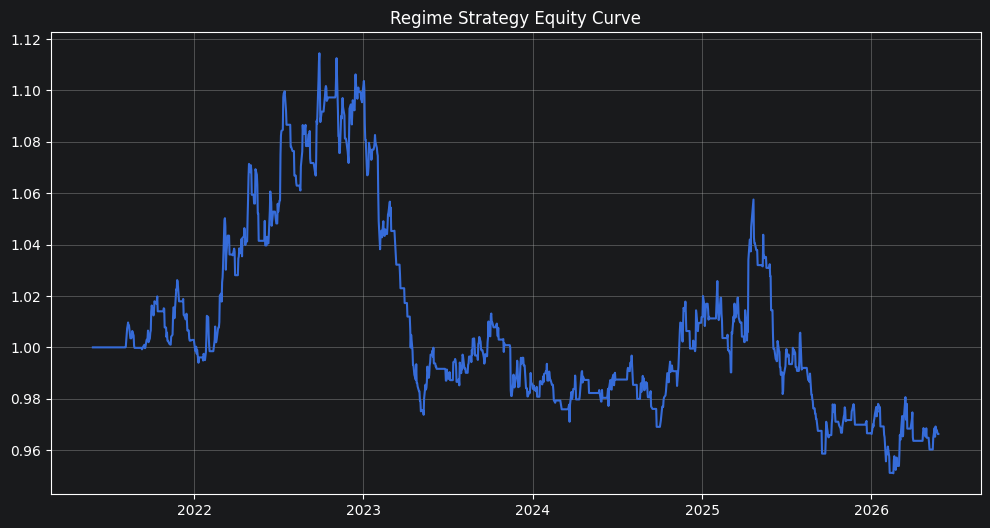

In [74]:
# we test regime based trading: i.e trading only when trend is strong, momentum align, adn trend align
trend_threshold = 0.02 # 2% from MA50


# we create the regime signal
data['regime_signal'] = np.where(
    (
    (data['momentum_5'] > 0)
    &
    (data['trend_strength'] > trend_threshold)
    ),
    1,
    np.where(
        (
        (data['momentum_5'] < 0)
        &
        (data['trend_strength'] < trend_threshold)
    ),
    -1,
    0
    )
)

# strategy return
data['regime_returns'] = (
    data['regime_signal'].shift(1)
    * data['returns']
)


# we calculate the return
# sharpe ratio

regime_sharpe = (
    data['regime_returns'].mean()
    /
    data['regime_returns'].std()
) * np.sqrt(252)
print(f"Regime Sharpe: {regime_sharpe}")


# we plot the equity curve
regime_equity = (
    1 + data['regime_returns']
).cumprod()

plt.figure(figsize=(12,6))
plt.plot(regime_equity)
plt.title("Regime Strategy Equity Curve")
plt.grid()
plt.show()

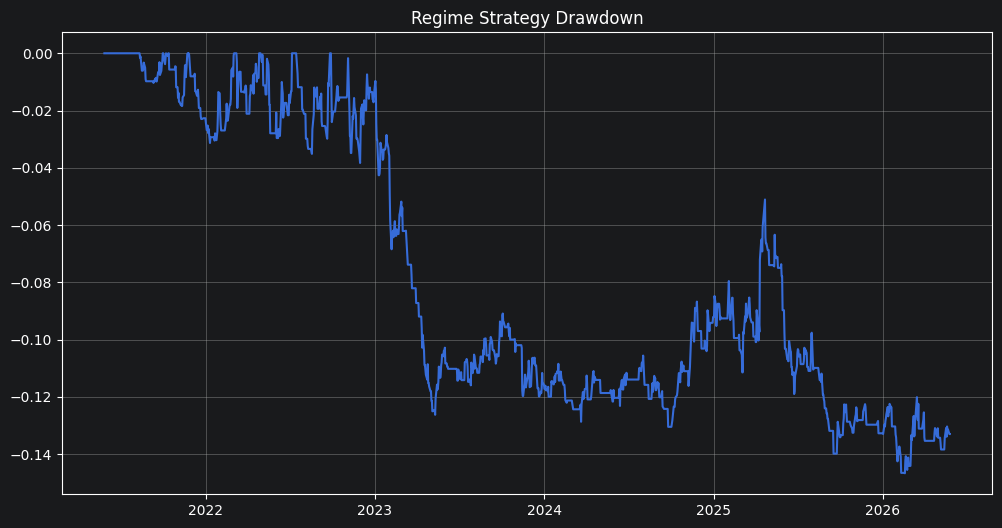

In [75]:
# we calculate regime drawdown
regime_rolling_max = (
    regime_equity.cummax()
)

regime_drawdown = (
    regime_equity - regime_rolling_max
) / regime_rolling_max

plt.figure(figsize=(12,6))
plt.plot(regime_drawdown)
plt.title("Regime Strategy Drawdown")
plt.grid()
plt.show()

    momentum_window  ma_window    sharpe
13               20         50  0.254983
14               20        100  0.243033
15               20        200  0.233430
5                 5         50  0.098339
12               20         20  0.068266
6                 5        100  0.052142
7                 5        200 -0.020257
9                10         50 -0.039300
4                 5         20 -0.102675
10               10        100 -0.111590
11               10        200 -0.197741
8                10         20 -0.220513
1                 3         50 -0.489600
2                 3        100 -0.551407
3                 3        200 -0.611431
0                 3         20 -0.658281

Best Momentum Window: 20.0
Best MA Window: 50.0


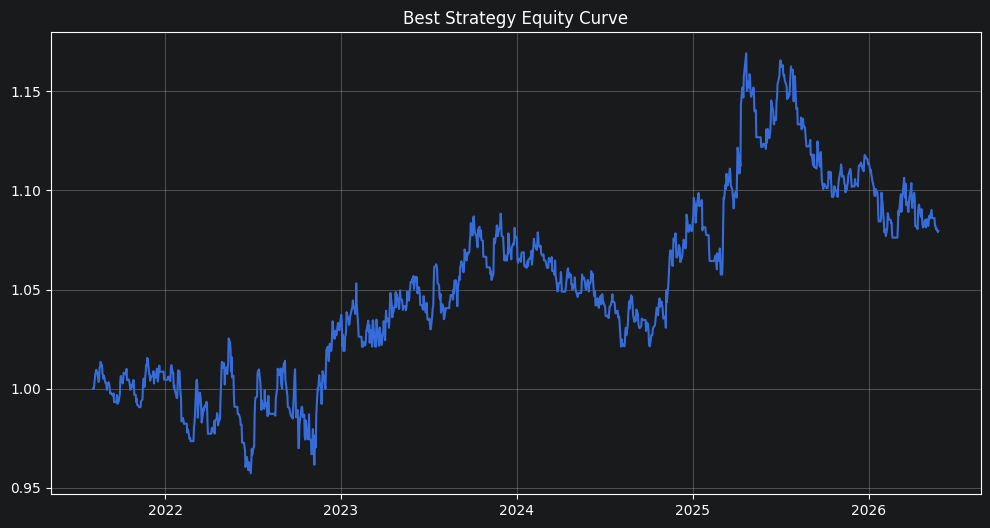

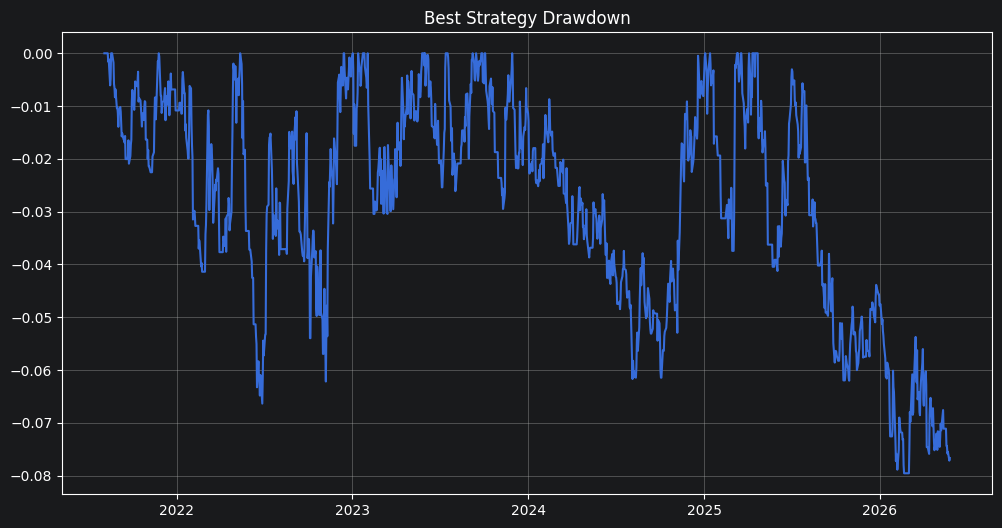

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETER SEARCH SPACE
# -----------------------------

momentum_windows = [3, 5, 10, 20]
ma_windows = [20, 50, 100, 200]

# store results
results = []

# -----------------------------
# LOOP THROUGH PARAMETERS
# -----------------------------

for mom_window in momentum_windows:

    for ma_window in ma_windows:

        # create temporary dataframe
        temp_data = data.copy()

        # -----------------------------
        # DYNAMIC FEATURES
        # -----------------------------

        temp_data['momentum_dynamic'] = (
            temp_data['Close']
            .squeeze()
            .pct_change(mom_window)
        )

        temp_data['ma_dynamic'] = (
            temp_data['Close']
            .squeeze()
            .rolling(ma_window)
            .mean()
        )

        # -----------------------------
        # REMOVE NaNs
        # -----------------------------

        temp_data = temp_data.dropna().copy()

        # -----------------------------
        # SIGNAL LOGIC
        # -----------------------------

        temp_data['signal_dynamic'] = np.where(

            (
                (temp_data['momentum_dynamic'] > 0)
                &
                (
                    temp_data['Close'].squeeze()
                    >
                    temp_data['ma_dynamic']
                )
            ),

            1,

            np.where(

                (
                    (temp_data['momentum_dynamic'] < 0)
                    &
                    (
                        temp_data['Close'].squeeze()
                        <
                        temp_data['ma_dynamic']
                    )
                ),

                -1,

                0
            )
        )

        # -----------------------------
        # STRATEGY RETURNS
        # -----------------------------

        temp_data['strategy_dynamic'] = (

            temp_data['signal_dynamic']
            .shift(1)

            *

            temp_data['returns']

        )

        # remove NaNs again
        temp_data = temp_data.dropna().copy()

        # -----------------------------
        # SHARPE RATIO
        # -----------------------------

        sharpe = (

            temp_data['strategy_dynamic'].mean()

            /

            temp_data['strategy_dynamic'].std()

        ) * np.sqrt(252)

        # -----------------------------
        # SAVE RESULTS
        # -----------------------------

        results.append({

            'momentum_window': mom_window,
            'ma_window': ma_window,
            'sharpe': sharpe

        })

# -----------------------------
# RESULTS DATAFRAME
# -----------------------------

results_df = pd.DataFrame(results)

# sort best results
results_df = results_df.sort_values(
    by='sharpe',
    ascending=False
)

# display results
print(results_df)

# -----------------------------
# BEST PARAMETER COMBINATION
# -----------------------------

best_momentum = results_df.iloc[0]['momentum_window']
best_ma = results_df.iloc[0]['ma_window']

print("\nBest Momentum Window:", best_momentum)
print("Best MA Window:", best_ma)

# -----------------------------
# REBUILD BEST STRATEGY
# -----------------------------

best_data = data.copy()

best_data['momentum'] = (
    best_data['Close']
    .squeeze()
    .pct_change(int(best_momentum))
)

best_data['ma'] = (
    best_data['Close']
    .squeeze()
    .rolling(int(best_ma))
    .mean()
)

best_data = best_data.dropna().copy()

# signals

best_data['signal'] = np.where(

    (
        (best_data['momentum'] > 0)
        &
        (
            best_data['Close'].squeeze()
            >
            best_data['ma']
        )
    ),

    1,

    np.where(

        (
            (best_data['momentum'] < 0)
            &
            (
                best_data['Close'].squeeze()
                <
                best_data['ma']
            )
        ),

        -1,

        0
    )
)

# returns

best_data['strategy_returns'] = (

    best_data['signal']
    .shift(1)

    *

    best_data['returns']

)

best_data = best_data.dropna().copy()

# -----------------------------
# EQUITY CURVE
# -----------------------------

best_data['equity_curve'] = (

    1 + best_data['strategy_returns']

).cumprod()

plt.figure(figsize=(12,6))

plt.plot(best_data['equity_curve'])

plt.title("Best Strategy Equity Curve")

plt.grid()

plt.show()

# -----------------------------
# DRAWDOWN
# -----------------------------

rolling_max = (
    best_data['equity_curve']
    .cummax()
)

drawdown = (

    best_data['equity_curve']
    -
    rolling_max

) / rolling_max

plt.figure(figsize=(12,6))

plt.plot(drawdown)

plt.title("Best Strategy Drawdown")

plt.grid()

plt.show()

In [ ]:
# PATTERN TRADING TURN TO QUANTITATIVE RESEARCH